In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import random

import cebra
import cebra.datasets
from cebra import CEBRA

import torch.nn as nn
from cebra.data.datatypes import Offset


# reload the data we dumped in cell 31

base = "./outputs/glm_input_data/"

beh_vals = np.load(os.path.join(base, "behavior_glm_input.npy"), allow_pickle=True)
beh_idx = np.load(os.path.join(base, "behavior_glm_input_index.npy"),
                  allow_pickle=True)
beh_cols = np.load(os.path.join(base, "behavior_glm_input_columns.npy"),
                   allow_pickle=True)

spk_vals = np.load(os.path.join(base, "fr_full.npy"))
spk_idx = np.load(os.path.join(base, "fr_full_index.npy"),
                  allow_pickle=True)
spk_cols = np.load(os.path.join(base, "fr_full_columns.npy"),
                   allow_pickle=True)

# fr_vals = np.load(os.path.join(base, "fr_full.npy"))
# fr_idx = np.load(os.path.join(base, "fr_full_index.npy"),
#                  allow_pickle=True)
# fr_cols = np.load(os.path.join(base, "fr_full_columns.npy"),
#                   allow_pickle=True)

# reconstruct indexes (they were saved as arrays of tuples)
try:
    beh_index = pd.MultiIndex.from_tuples(beh_idx,
                                          names=behavior_glm_input.index.names)
except Exception:
    beh_index = pd.Index(beh_idx)

try:
    spk_index = pd.MultiIndex.from_tuples(spk_idx,
                                          names=fr_first7.index.names)
except Exception:
    spk_index = pd.Index(spk_idx)

try:
    fr_index = pd.MultiIndex.from_tuples(fr_idx, names=fr.index.names)
except Exception:
    fr_index = pd.Index(fr_idx)

# build dataframes
behavior_glm_loaded = pd.DataFrame(beh_vals,
                                   index=beh_index,
                                   columns=beh_cols)
spikes_loaded = pd.DataFrame(spk_vals,
                             index=spk_index,
                             columns=spk_cols)
# fr_full_loaded = pd.DataFrame(fr_vals,
#                               index=fr_index,
#                               columns=fr_cols)

print("behavior_glm_loaded shape", behavior_glm_loaded.shape)
print("spikes_loaded shape", spikes_loaded.shape)
# print("fr_full_loaded shape", fr_full_loaded.shape)

In [ ]:
class LSTM(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = torch.nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, output_size),
            # torch.nn.Sigmoid()
        )

    def forward(self, x):
        # accept (seq_len, input_size) or (batch, seq_len, input_size)
        added_batch = False
        if x.dim() == 2:  # (seq_len, input_size) -> (1, seq_len, input_size)
            x = x.unsqueeze(0)
            added_batch = True

        batch = x.size(0)
        h0 = x.new_zeros(1, batch, self.hidden_size)
        c0 = x.new_zeros(1, batch, self.hidden_size)

        lstm_out, (hn, cn) = self.lstm(x, (h0, c0))  # (batch, seq_len, hidden_size)
        out = self.fc(lstm_out)  # (batch, seq_len, output_size)

        if added_batch:
            lstm_out = lstm_out.squeeze(0)  # (seq_len, hidden_size)
            out = out.squeeze(0)            # (seq_len, output_size)

        return lstm_out, out
    
class RNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = torch.nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, output_size),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        # accept (seq_len, input_size) or (batch, seq_len, input_size)
        added_batch = False
        if x.dim() == 2:  # (seq_len, input_size) -> (1, seq_len, input_size)
            x = x.unsqueeze(0)
            added_batch = True

        batch = x.size(0)
        h0 = x.new_zeros(1, batch, self.hidden_size)

        rnn_out, hn = self.rnn(x, h0)  # (batch, seq_len, hidden_size)
        out = self.fc(rnn_out)         # (batch, seq_len, output_size)

        if added_batch:
            rnn_out = rnn_out.squeeze(0)  # (seq_len, hidden_size)
            out = out.squeeze(0)            # (seq_len, output_size)

        return rnn_out, out
    
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_hidden_layers, output_size):
        assert num_hidden_layers >= 1
        super(MLP, self).__init__()
        self.hidden_size = hidden_size
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(input_size, hidden_size),
            torch.nn.ReLU(),
            *([torch.nn.Linear(hidden_size, hidden_size), torch.nn.ReLU()] * (num_hidden_layers - 1)),
            torch.nn.Linear(hidden_size, output_size),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return None, self.fc(x)


: 

In [3]:
behavior_glm_loaded.columns

Index(['frame_raw_500msMedian', 'frame_raw_abs_acc_500msMedian',
       'frame_YawPitch_abs_vel_sum_500msMedian',
       'frame_YawPitch_abs_acc_sum_500msMedian',
       'frame_RawYawPitch_abs_vel_sum_500msMedian',
       'frame_RawYawPitch_abs_acc_sum_500msMedian', 'frame_forward_prop',
       'forward_vs_rotation_corr', 'frame_position', 'head_angle_vel',
       'head_angle', 'movement_energy_smooth5', 'frame_ephys_timestamp',
       'frame_pc_timestamp', 'trial_id', 'cue', 'trial_outcome', 'choice_R1',
       'choice_R2', 'lick_detected', 'reward-sound_detected',
       'reward-valve-open_detected', 'track_zone', 'track_zone_int',
       'cue_visible', 'from_ephys_timestamp', 'to_ephys_timestamp'],
      dtype='object')

In [4]:
behavior_glm_loaded["track_zone"].unique()

array([nan, 'startZone', 'visibleCue', 'nextToCue', 'afterCue',
       'reward1Zone', 'bewteenRewardZones', 'reward2Zone', 'endZone',
       'ITI'], dtype=object)

In [5]:
spikes_loaded.index = pd.MultiIndex.from_tuples(
    spikes_loaded.index.map(lambda t: (t[0], t[1] // 40000 - 1))
)

In [6]:
spikes_loaded

Unit0001  Unit0002  Unit0003  Unit0004  Unit0005  \
2024-11-14_16-40 0             0         0         0         0         0   
                 1             0         0         0         0         0   
                 2             0         0         0         0         0   
                 3             0         0         0         0         0   
                 4             0         0         0         0         0   
...                          ...       ...       ...       ...       ...   
2024-11-28_17-41 46114         0         0         0         0         0   
                 46115         0         0         0         0         0   
                 46116         0         0         0         0         0   
                 46117         0         0         0         0         0   
                 46118         0         0         0         0         0   

                        Unit0006  Unit0007  Unit0008  Unit0009  Unit0010  ...  \
2024-11-14_16-40 0             0         0         0         0         0  ...   
                 1             0         0         0         0         0  ...   
                 2             0         0         0         0         0  ...   
                 3             0         0         0         0         0  ...   
                 4             0         0         0         0         0  ...   
...                          ...       ...       ...       ...       ...  ...   
2024-11-28_17-41 46114         0         0         0         0         0  ...   
                 46115         0         0         0         0         0  ...   
                 46116         0         0         0         0         0  ...   
                 46117         0         0         0         0         0  ...   
                 46118         0         0         0         0         0  ...   

                        Unit0068  Unit0069  Unit0070  Unit0071  Unit0072  \
2024-11-14_16-40 0             0         0         0         0         0   
                 1             0         0         0         0         0   
                 2             0         0         0         0         0   
                 3             0         0         0         0         0   
                 4             0         0         0         0         0   
...                          ...       ...       ...       ...       ...   
2024-11-28_17-41 46114         0         0         0         0         0   
                 46115         0         0        25         0         0   
                 46116         0         0         0         0         0   
                 46117        25        25        25         0         0   
                 46118         0         0         0        25        25   

                        Unit0073  Unit0074  Unit0075  Unit0076  Unit0077  
2024-11-14_16-40 0             0         0         0         0         0  
                 1             0         0         0         0         0  
                 2             0         0         0         0         0  
                 3             0         0         0         0         0  
                 4             0         0         0         0         0  
...                          ...       ...       ...       ...       ...  
2024-11-28_17-41 46114         0        25         0         0         0  
                 46115         0         0         0         0         0  
                 46116         0         0         0         0         0  
                 46117         0         0         0        25         0  
                 46118         0         0         0        25         0  

[270222 rows x 77 columns]

In [7]:
spikes_unique_trials = set()
for idx in spikes_loaded.index:
    spikes_unique_trials.add(idx[0])

In [8]:
behavior_glm_loaded = behavior_glm_loaded[behavior_glm_loaded.index.map(lambda t: t[0] in spikes_unique_trials)]

In [9]:
non_nan_rows = behavior_glm_loaded.index[~behavior_glm_loaded.isna().any(axis=1)]
behavior_glm_loaded = behavior_glm_loaded.loc[non_nan_rows]
spikes_loaded = spikes_loaded.loc[non_nan_rows]

In [10]:
unique_trials = set()

for idx in behavior_glm_loaded.index:
    unique_trials.add(idx[0])

In [11]:
# Select only numeric columns
behavior_glm_loaded = behavior_glm_loaded.drop("track_zone", axis=1)

In [12]:
behavior_glm_loaded.columns

Index(['frame_raw_500msMedian', 'frame_raw_abs_acc_500msMedian',
       'frame_YawPitch_abs_vel_sum_500msMedian',
       'frame_YawPitch_abs_acc_sum_500msMedian',
       'frame_RawYawPitch_abs_vel_sum_500msMedian',
       'frame_RawYawPitch_abs_acc_sum_500msMedian', 'frame_forward_prop',
       'forward_vs_rotation_corr', 'frame_position', 'head_angle_vel',
       'head_angle', 'movement_energy_smooth5', 'frame_ephys_timestamp',
       'frame_pc_timestamp', 'trial_id', 'cue', 'trial_outcome', 'choice_R1',
       'choice_R2', 'lick_detected', 'reward-sound_detected',
       'reward-valve-open_detected', 'track_zone_int', 'cue_visible',
       'from_ephys_timestamp', 'to_ephys_timestamp'],
      dtype='object')

In [13]:
x = behavior_glm_loaded[behavior_glm_loaded.index.map(lambda t: t[0] == "2024-11-28_17-41")]
x.columns

Index(['frame_raw_500msMedian', 'frame_raw_abs_acc_500msMedian',
       'frame_YawPitch_abs_vel_sum_500msMedian',
       'frame_YawPitch_abs_acc_sum_500msMedian',
       'frame_RawYawPitch_abs_vel_sum_500msMedian',
       'frame_RawYawPitch_abs_acc_sum_500msMedian', 'frame_forward_prop',
       'forward_vs_rotation_corr', 'frame_position', 'head_angle_vel',
       'head_angle', 'movement_energy_smooth5', 'frame_ephys_timestamp',
       'frame_pc_timestamp', 'trial_id', 'cue', 'trial_outcome', 'choice_R1',
       'choice_R2', 'lick_detected', 'reward-sound_detected',
       'reward-valve-open_detected', 'track_zone_int', 'cue_visible',
       'from_ephys_timestamp', 'to_ephys_timestamp'],
      dtype='object')

In [14]:
behavior_glm_loaded["track_zone_int"].unique()

array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], dtype=object)

In [15]:
x = behavior_glm_loaded[behavior_glm_loaded.index.map(lambda t: t[0] == "2024-11-28_17-41")]
x = x["cue"].unique()
x

array([1.0, 2.0], dtype=object)

In [16]:
behavior_glm_loaded.index.map(lambda t: t[0]).unique()

Index(['2024-11-14_16-40', '2024-11-15_15-48', '2024-11-20_17-46',
       '2024-11-21_17-22', '2024-11-25_16-25', '2024-11-26_16-39',
       '2024-11-28_17-41'],
      dtype='object')

In [17]:
behavior_glm_loaded[behavior_glm_loaded["cue"] == 0].index.map(lambda t: t[0]).unique()

Index(['2024-11-15_15-48', '2024-11-20_17-46', '2024-11-21_17-22'], dtype='object')

In [18]:
behavior_glm_loaded["trial_outcome"].unique()

array([0.0, 10.0, 1.0, 11.0, 12.0, 20.0, 25.0, 2.0, 13.0, 3.0, 22.0, 21.0,
       5.0, 31.0, 15.0, 14.0, 23.0, 4.0, 55.0, 51.0, 30.0, 40.0],
      dtype=object)

In [19]:
behavior_glm_loaded["cue"].unique()

array([1.0, 2.0, 0.0], dtype=object)

In [20]:
last_only = behavior_glm_loaded[behavior_glm_loaded.index.map(lambda t: t[0] == "2024-11-28_17-41")]
last_only_1 = last_only[last_only["cue"] == 1]
last_only_2 = last_only[last_only["cue"] == 2]

fr_last_only = spikes_loaded[behavior_glm_loaded.index.map(lambda t: t[0] == "2024-11-28_17-41")]
fr_last_only_1 = fr_last_only[last_only["cue"] == 1]
fr_last_only_2 = fr_last_only[last_only["cue"] == 2]


assert len(last_only_1) + len(last_only_2) == len(last_only)

In [21]:
len(last_only_1["trial_id"].unique()), len(last_only_2["trial_id"].unique()), len(last_only["trial_id"].unique())

(64, 69, 133)

In [22]:
import statsmodels.api as sm



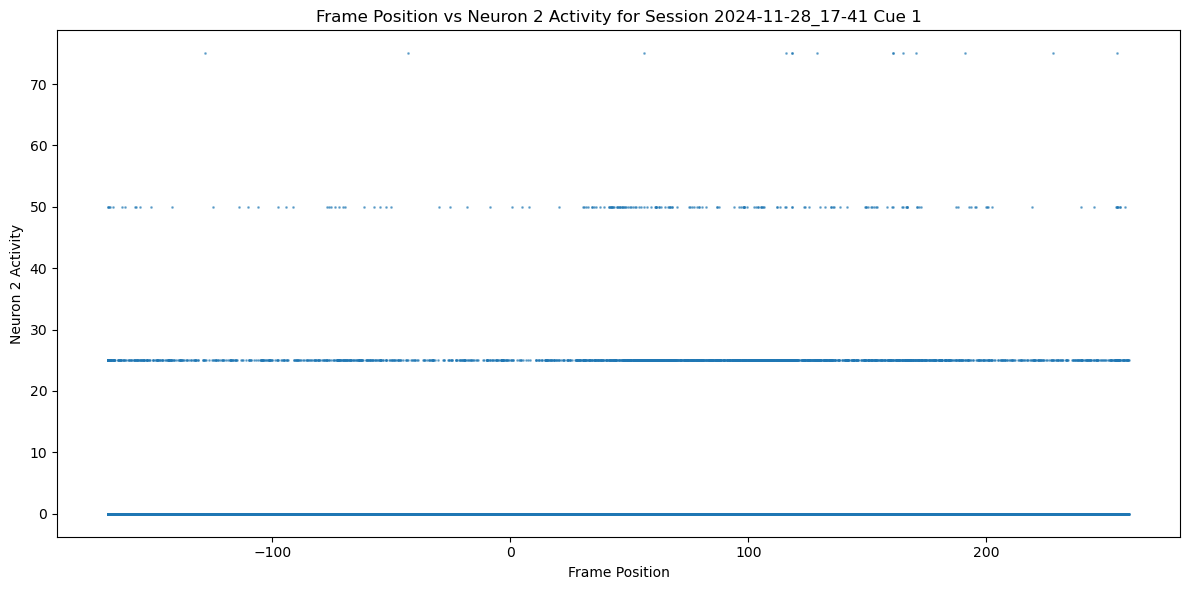

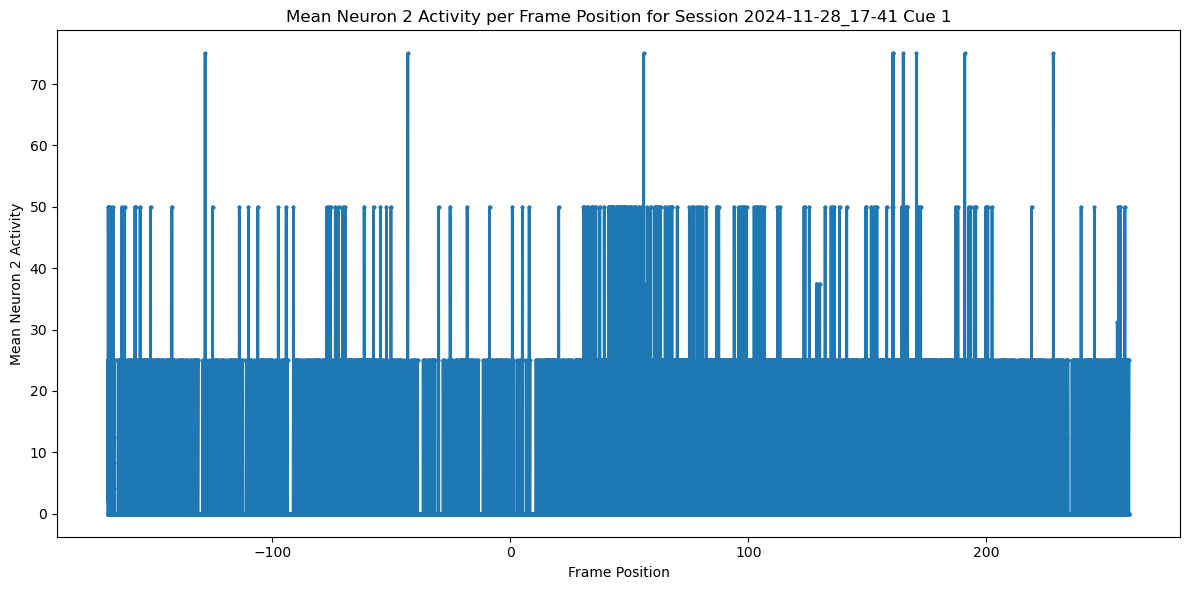

In [23]:
import matplotlib.pyplot as plt

# Extract frame_position from behavior_glm_loaded
frame_position = last_only_1['frame_position'].values

# Extract neuron 2 from spikes_loaded
neuron_1 = fr_last_only_1.iloc[:, 1].values

# Create scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(frame_position, neuron_1, s=1, alpha=0.5)
plt.xlabel('Frame Position')
plt.ylabel('Neuron 2 Activity')
plt.title(f'Frame Position vs Neuron 2 Activity for Session 2024-11-28_17-41 Cue 1')
plt.tight_layout()
plt.show()

# Plot mean neuron activity per frame position
frame_position_unique = np.unique(frame_position)
mean_neuron_1_per_frame = []

for fp in frame_position_unique:
    mask = frame_position == fp
    mean_neuron_1_per_frame.append(neuron_1[mask].mean())

plt.figure(figsize=(12, 6))
plt.plot(frame_position_unique, mean_neuron_1_per_frame, linewidth=2, marker='o', markersize=2)
plt.xlabel('Frame Position')
plt.ylabel('Mean Neuron 2 Activity')
plt.title('Mean Neuron 2 Activity per Frame Position for Session 2024-11-28_17-41 Cue 1')
plt.tight_layout()
plt.show()


In [24]:
import statsmodels.api as sm
import numpy as np

# --- your existing data extraction ---
frame_position_1 = last_only_1['frame_position'].values
neuron_1_cue1 = fr_last_only_1.iloc[:, 1].values

frame_position_2 = last_only_2['frame_position'].values
neuron_1_cue2 = fr_last_only_2.iloc[:, 1].values

# --- combine both cues ---
position = np.concatenate([frame_position_1, frame_position_2])
spikes   = np.concatenate([neuron_1_cue1, neuron_1_cue2])
cue      = np.concatenate([np.zeros(len(frame_position_1)),   # cue 1 = 0
                            np.ones(len(frame_position_2))])   # cue 2 = 1

# --- remove NaNs ---
# valid = ~(np.isnan(position) | np.isnan(spikes))
# position, spikes, cue = position[valid], spikes[valid], cue[valid]

position = position.astype(np.float64)
spikes   = spikes.astype(np.float64)
cue      = cue.astype(np.float64)

# --- fit NB GLM with position, cue, and their interaction ---
mu  = spikes.mean()
var = spikes.var()
alpha = (var - mu) / (mu ** 2) if var > mu else 1.0  # estimated dispersion

X = sm.add_constant(np.column_stack([
    position,
    cue,
    position * cue   # interaction: does tuning curve shape differ per cue?
]))

model  = sm.GLM(spikes, X, family=sm.families.NegativeBinomial(alpha=alpha))
result = model.fit()
print(result.summary())

# --- null model for comparison ---
X_null  = np.ones((len(spikes), 1))
result_null = sm.GLM(spikes, X_null,
                     family=sm.families.NegativeBinomial(alpha=alpha)).fit()

# --- likelihood ratio test ---
from scipy.stats import chi2
lr_stat = 2 * (result.llf - result_null.llf)
p_value = chi2.sf(lr_stat, df=result.df_model)
pseudo_r2 = result.pseudo_rsquared()

print(f"\nLikelihood ratio p-value : {p_value:.4e}")
print(f"Pseudo R²                : {pseudo_r2:.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                34718
Model:                            GLM   Df Residuals:                    34714
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -48162.
Date:                Wed, 25 Mar 2026   Deviance:                       39005.
Time:                        11:30:11   Pearson chi2:                 3.47e+04
No. Iterations:                     9   Pseudo R-squ. (CS):          0.0003091
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3760      0.021     65.248      0.0

In [25]:
# bin position
bin_size = 20
position_binned = (position // bin_size * bin_size).astype(int)

# one-hot encode position bins + cue
import pandas as pd
X_cat = pd.get_dummies(pd.DataFrame({
    'pos_bin': position_binned,
    'cue': cue.astype(int)
}), columns=['pos_bin'], drop_first=True)
X_cat = sm.add_constant(X_cat.astype(float))

model = sm.GLM(spikes, X_cat, 
               family=sm.families.NegativeBinomial(alpha=alpha))
result = model.fit()

print(result.summary())

# --- likelihood ratio test ---
from scipy.stats import chi2
lr_stat = 2 * (result.llf - result_null.llf)
p_value = chi2.sf(lr_stat, df=result.df_model)
pseudo_r2 = result.pseudo_rsquared()

print(f"\nLikelihood ratio p-value : {p_value:.4e}")
print(f"Pseudo R²                : {pseudo_r2:.4f}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                34718
Model:                            GLM   Df Residuals:                    34695
Model Family:        NegativeBinomial   Df Model:                           22
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -47996.
Date:                Wed, 25 Mar 2026   Deviance:                       38674.
Time:                        11:30:12   Pearson chi2:                 3.64e+04
No. Iterations:                     9   Pseudo R-squ. (CS):           0.009791
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.2337      0.057     21.767   

In [26]:
# Step 1: compute neural population vectors per timepoint
# using fr_full_loaded, shape (T, 77)

# Step 2: compute pairwise neural distances (subsample for tractability)
from sklearn.metrics.pairwise import euclidean_distances
idx = np.random.choice(len(fr_last_only), 2000, replace=False)
D_neural = euclidean_distances(fr_last_only[["Unit0002"]].values[idx])

# Step 3: compute pairwise action distances  
action_vecs = last_only[["frame_position", "cue"]].values[idx]  # (2000, 14)
D_action = euclidean_distances(action_vecs)

# Step 4: are neural distances and action distances correlated?
from scipy.stats import spearmanr
tri = np.tril_indices(2000, k=-1)
r, p = spearmanr(D_neural[tri], D_action[tri])
print(f"Mantel test r={r:.3f}, p={p:.4e}")

Mantel test r=-0.017, p=7.3588e-122


In [27]:
# for outcome, label in [(True, 'correct'), (False, 'incorrect')]:
#     mask = label_df['correct'] == outcome
    
#     sub_action  = trial_df[mask].fillna(0)
#     sub_neural  = neural_df[mask].fillna(0)
    
#     if len(sub_action) < 10:
#         print(f"{label}: not enough trials")
#         continue
    
#     D_action = euclidean_distances(sub_action)
#     D_neural = euclidean_distances(sub_neural)
    
#     tri = np.tril_indices(len(sub_action), k=-1)
#     r, p = spearmanr(D_action[tri], D_neural[tri])
#     print(f"{label:>10}  n={mask.sum():>3}  r={r:.3f}  p={p:.4e}")

In [28]:
behavior_glm_loaded.index.get_level_values(0).map(lambda t: t[0]).unique()

Index(['2024-11-14_16-40', '2024-11-15_15-48', '2024-11-20_17-46',
       '2024-11-21_17-22', '2024-11-25_16-25', '2024-11-26_16-39',
       '2024-11-28_17-41'],
      dtype='object')

In [29]:
results = []

action_enc_cols = [
    'frame_raw_500msMedian',                  # forward_velocity
    'frame_raw_abs_acc_500msMedian',          # forward_acceleration
    'frame_YawPitch_abs_vel_sum_500msMedian', # off_rotation_velocity
    'frame_YawPitch_abs_acc_sum_500msMedian', # off_rotation_acceleration
    'head_angle_vel',
    'head_angle',
    'movement_energy_smooth5',                # movement_energy
    'upcoming_choice',
    'reward_window',
    'lick_detected',
]
state_enc_cols = [
    'cue_visible',
    'track_zone',
]

all_train_labels = []
for session_id in behavior_glm_loaded.index.get_level_values(0).map(lambda t: t[0]).unique():
    print(f"Session ID: {session_id}")
    trial_vectors_s = []
    trial_labels_s  = []

    beh = behavior_glm_loaded[
        behavior_glm_loaded.index.map(lambda t: t[0] == session_id)
    ]

    beh = beh[beh["cue"] != 0]

    diffs = 0
    totals = 0


    for trial_id in beh['trial_id'].unique():
        trial = beh[beh['trial_id'] == trial_id]

        approach = trial[
            ((trial['cue'] == 1) & (trial['track_zone_int'] == 4)) |
            ((trial['cue'] == 2) & (trial['track_zone_int'] == 6))
        ]

        if len(approach) < 5:
            continue

        vec     = approach[action_enc_cols].mean()
        outcome = (((trial['choice_R1'] == 1) & (trial['cue'] == 1)) | ((trial['choice_R2'] == 1) & (trial['cue'] == 2))).iloc[0]
        outcome_to =  (trial['trial_outcome'] > 0.5).iloc[0]
        if not (outcome == outcome_to):
            # print(f'Trial No: {trial_id}, Cue: {trial["cue"].iloc[0]}, R1?: {(trial["choice_R1"] == 1).iloc[0]}, R2?: {(trial["choice_R2"] == 1).iloc[0]}, Trial Outcome: {(trial["trial_outcome"]).iloc[0]}')
            diffs += 1
            totals += 1
        else:
            totals += 1

        outcome = outcome_to

        cue     = trial['cue'].max()

        trial_vectors_s.append(vec)
        trial_labels_s.append({
            'session': session_id,
            'trial':   trial_id,
            'correct': outcome,
            'cue':     cue
        })

    print(f"{diffs}/{totals} different")

    if len(trial_vectors_s) < 10:
        continue

    trial_df_s = pd.DataFrame(trial_vectors_s)
    label_df_s = pd.DataFrame(trial_labels_s)

    # neural vectors for this session
    neural_vectors_s = []
    for _, row in label_df_s.iterrows():
        beh_session  = behavior_glm_loaded[
            behavior_glm_loaded.index.map(lambda t: t[0] == row['session'])
        ]
        trial_beh    = beh_session[beh_session['trial_id'] == row['trial']]
        approach_mask = (
            ((trial_beh['choice_R1'] == 1) & (trial_beh['track_zone_int'] == 4)) |
            ((trial_beh['choice_R2'] == 1) & (trial_beh['track_zone_int'] == 6))
        )
        approach_beh = trial_beh[approach_mask]

        fr_session   = spikes_loaded[
            spikes_loaded.index.map(lambda t: t[0] == row['session'])
        ]

        if len(approach_beh) == 0:
            neural_vectors_s.append(pd.Series(np.nan, index=spikes_loaded.columns))
            continue

        fr_approach  = fr_session.loc[fr_session.index.isin(approach_beh.index)]
        neural_vectors_s.append(fr_approach.mean())

    neural_df_s = pd.DataFrame(neural_vectors_s)

    # Mantel per outcome
    for outcome, label in [(True, 'correct'), (False, 'incorrect')]:
        mask = label_df_s['correct'] == outcome
        
        if mask.sum() < 10:
            continue

        D_a = euclidean_distances(trial_df_s[mask].fillna(0))
        D_n = euclidean_distances(neural_df_s[mask].fillna(0))
        tri = np.tril_indices(mask.sum(), k=-1)
        r, p = spearmanr(D_a[tri], D_n[tri])

        # print(mask.sum(), len(label_df_s[label_df_s["correct"] == outcome]))

        results.append({
            'session':  session_id,
            'outcome':  label,
            'n':        mask.sum(),
            'r':        r,
            'p':        p
        })
        print(f"{session_id}  {label:>10}  n={mask.sum():>3}  r={r:.3f}  p={p:.4e}")

    all_train_labels.extend(trial_labels_s)

results_df = pd.DataFrame(results)
all_train_labels_df = pd.DataFrame(all_train_labels)

Session ID: 2024-11-14_16-40
21/102 different
2024-11-14_16-40     correct  n= 22  r=0.111  p=9.1995e-02
2024-11-14_16-40   incorrect  n= 80  r=-0.026  p=1.4118e-01
Session ID: 2024-11-15_15-48
15/120 different
2024-11-15_15-48     correct  n= 54  r=0.136  p=2.2845e-07
2024-11-15_15-48   incorrect  n= 66  r=0.060  p=5.6220e-03
Session ID: 2024-11-20_17-46
4/66 different
2024-11-20_17-46     correct  n= 18  r=0.123  p=1.3049e-01
2024-11-20_17-46   incorrect  n= 48  r=0.184  p=4.5238e-10
Session ID: 2024-11-21_17-22
12/66 different
2024-11-21_17-22     correct  n= 40  r=0.108  p=2.6063e-03
2024-11-21_17-22   incorrect  n= 26  r=-0.193  p=4.6128e-04
Session ID: 2024-11-25_16-25
9/49 different
2024-11-25_16-25     correct  n= 27  r=0.113  p=3.3736e-02
2024-11-25_16-25   incorrect  n= 22  r=-0.019  p=7.7568e-01
Session ID: 2024-11-26_16-39
13/87 different
2024-11-26_16-39     correct  n= 58  r=0.327  p=1.8115e-42
2024-11-26_16-39   incorrect  n= 29  r=-0.049  p=3.2925e-01
Session ID: 2024-1

In [30]:
results_df

,session,outcome,n,r,p
0,2024-11-14_16-40,correct,22,0.111122,9.199549e-02
1,2024-11-14_16-40,incorrect,80,-0.026181,1.411784e-01
2,2024-11-15_15-48,correct,54,0.136270,2.284452e-07
3,2024-11-15_15-48,incorrect,66,0.059770,5.622023e-03
4,2024-11-20_17-46,correct,18,0.122797,1.304862e-01
5,2024-11-20_17-46,incorrect,48,0.184251,4.523786e-10
6,2024-11-21_17-22,correct,40,0.107660,2.606258e-03
7,2024-11-21_17-22,incorrect,26,-0.193183,4.612753e-04
8,2024-11-25_16-25,correct,27,0.113367,3.373610e-02
9,2024-11-25_16-25,incorrect,22,-0.018850,7.756756e-01


In [31]:
results_df[results_df["outcome"] == "correct"]["n"].sum()

np.int64(273)

In [32]:
# for sid in ['2024-11-14_16-40', '2024-11-15_15-48', '2024-11-20_17-46',
#        '2024-11-21_17-22', '2024-11-25_16-25', '2024-11-26_16-39',
#        '2024-11-28_17-41']:
#     beh = behavior_glm_loaded[
#             behavior_glm_loaded.index.map(lambda t: t[0] == sid)
#         ]
#     correct_mask = (((beh['choice_R1'] == 1) & (beh['cue'] == 1)) | ((beh['choice_R2'] == 1) & (beh['cue'] == 2)))
#     if len(beh[correct_mask]['cue'].unique()) == 2:
#         print(sid)
#         print(len(beh[correct_mask][beh['cue'] == 1]), len(beh[correct_mask][beh['cue'] == 2]))

In [33]:
#check if there are any correct of the other cue?
# trial_df_correct['cue'].unique()

In [34]:
all_train_labels_df[all_train_labels_df["correct"]]

,session,trial,correct,cue
2,2024-11-14_16-40,3.0,True,2.0
9,2024-11-14_16-40,10.0,True,2.0
13,2024-11-14_16-40,14.0,True,1.0
21,2024-11-14_16-40,22.0,True,1.0
34,2024-11-14_16-40,35.0,True,1.0
...,...,...,...,...
611,2024-11-28_17-41,122.0,True,1.0
614,2024-11-28_17-41,125.0,True,1.0
615,2024-11-28_17-41,126.0,True,1.0
617,2024-11-28_17-41,128.0,True,1.0


In [35]:
rs = []
ps= []
window_sizes = [10, 25, 50, 100, 200, 250]
for window_size in window_sizes:  # 100 × 40ms = 4s around zone entry

    trial_neural_seqs = []
    trial_action_seqs = []

    for _, row in all_train_labels_df[all_train_labels_df["correct"]].iterrows():
        # get zone entry timepoint
        beh_session = behavior_glm_loaded[
            behavior_glm_loaded.index.map(lambda t: t[0] == row['session'])
        ]
        trial_beh = beh_session[beh_session['trial_id'] == row['trial']]
        # print(beh_session.head())
        
        for stop_zone in [1, 2]:
            
            # find first timepoint in reward zone
            if stop_zone == 1:
                zone_entry_idx = trial_beh[
                    ((trial_beh['track_zone_int'] == 4) & (trial_beh['choice_R1'] == 1))
                ].index
            else:
                zone_entry_idx = trial_beh[
                    ((trial_beh['track_zone_int'] == 6) & (trial_beh['choice_R2'] == 1))
                ].index
            
            if len(zone_entry_idx) < window_size:
                continue
            
            # take first window_size timepoints from zone entry
            window_idx = zone_entry_idx[:window_size]
            mask = trial_beh.index.isin(window_idx)

            
            # neural sequence: (window_size × 77) → flatten to 1D
            fr_session = spikes_loaded[spikes_loaded.index.map(lambda t: t[0] == row['session'])]
            trial_fr = fr_session[beh_session['trial_id'] == row['trial']]
            neural_window = trial_fr.loc[mask].values
            
            # action sequence: (window_size × n_features) → flatten
            action_window = trial_beh.loc[window_idx][action_enc_cols].values
            
            if neural_window.shape[0] == window_size and action_window.shape[0] == window_size:
                trial_neural_seqs.append(neural_window.flatten())
                trial_action_seqs.append(action_window.flatten())

    print(f"window={window_size:>4}  n_trials={len(trial_neural_seqs)}")
    neural_seq_df = pd.DataFrame(trial_neural_seqs)
    action_seq_df = pd.DataFrame(trial_action_seqs)

    D_a = euclidean_distances(action_seq_df.fillna(0))
    D_n = euclidean_distances(neural_seq_df.fillna(0))
    mask = np.array([1] * len(action_seq_df))
    tri = np.tril_indices(mask.sum(), k=-1)
    r, p = spearmanr(D_a[tri], D_n[tri])
    rs.append(r)
    ps.append(p)

print(f"window sizes: {window_sizes}\nr: {rs}\np: {ps}")

window=  10  n_trials=408
window=  25  n_trials=408
window=  50  n_trials=370
window= 100  n_trials=99
window= 200  n_trials=18
window= 250  n_trials=12
window sizes: [10, 25, 50, 100, 200, 250]
r: [np.float64(0.08941308559475021), np.float64(0.10298492680395255), np.float64(0.1448461157311844), np.float64(0.27053213528168524), np.float64(0.27673866335041586), np.float64(0.4643196359676352)]
p: [np.float64(5.965621621606371e-147), np.float64(1.568861275814747e-194), np.float64(0.0), np.float64(3.9574070058879595e-82), np.float64(0.0005344285022930669), np.float64(8.596135988357087e-05)]


In [84]:
r

np.float64(0.48571428571428577)

In [55]:
fr_session.shape

(46119, 77)

In [ ]:
# filter to correct trials only
correct_mask = beh['trial_outcome'] >0.5
approach_mask = (correct_mask &
    (((beh['choice_R1'] == 1) & (beh['track_zone_int'] == 4)) |
    ((beh['choice_R2'] == 1) & (beh['track_zone_int'] == 6))))

trial_df_correct = beh[approach_mask].reset_index(drop=True)[action_enc_cols]
neural_df_correct = fr_session[approach_mask].reset_index(drop=True)

# action distance matrix on correct trials only
D_action_correct = euclidean_distances(trial_df_correct.fillna(0))
tri = np.tril_indices(len(trial_df_correct), k=-1)

# per-unit correlation with action distances
unit_correlations = []
for unit_idx in range(neural_df_correct.shape[1]):
    unit_activity = neural_df_correct.iloc[:, unit_idx].fillna(0).values
    D_unit = np.abs(unit_activity[:, None] - unit_activity[None, :])
    r, p = spearmanr(D_action_correct[tri], D_unit[tri])
    unit_correlations.append({
        'unit': neural_df_correct.columns[unit_idx],
        'r': r,
        'p': p
    })

unit_df = pd.DataFrame(unit_correlations).sort_values('r', ascending=False)

# select informative units
selected_units = unit_df[(unit_df['r'] > 0.01) & (unit_df['p'] < 0.05)]['unit'].tolist()
print(f"Selected {len(selected_units)} / {neural_df_correct.shape[1]} units")
print(unit_df[unit_df['unit'].isin(selected_units)])

/tmp/ipykernel_8757/891322714.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  D_action_correct = euclidean_distances(trial_df_correct.fillna(0))
/tmp/ipykernel_8757/891322714.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(D_action_correct[tri], D_unit[tri])


Selected 33 / 77 units
        unit         r    p
25  Unit0026  0.126968  0.0
48  Unit0049  0.121336  0.0
56  Unit0057  0.112191  0.0
23  Unit0024  0.076029  0.0
50  Unit0051  0.064529  0.0
15  Unit0016  0.049628  0.0
14  Unit0015  0.047657  0.0
68  Unit0069  0.044327  0.0
4   Unit0005  0.033581  0.0
60  Unit0061  0.029408  0.0
1   Unit0002  0.028427  0.0
29  Unit0030  0.028002  0.0
24  Unit0025  0.026285  0.0
27  Unit0028  0.023677  0.0
58  Unit0059  0.023596  0.0
65  Unit0066  0.022134  0.0
32  Unit0033  0.022015  0.0
21  Unit0022  0.019107  0.0
36  Unit0037  0.018253  0.0
34  Unit0035  0.017519  0.0
38  Unit0039  0.016398  0.0
71  Unit0072  0.015611  0.0
26  Unit0027  0.014380  0.0
20  Unit0021  0.012877  0.0
73  Unit0074  0.012612  0.0
12  Unit0013  0.011778  0.0
6   Unit0007  0.011700  0.0
76  Unit0077  0.011540  0.0
0   Unit0001  0.010747  0.0
59  Unit0060  0.010337  0.0
72  Unit0073  0.010335  0.0
28  Unit0029  0.010227  0.0
70  Unit0071  0.010035  0.0


In [115]:
beh.index.map(lambda x: x[0]).unique()

Index(['2024-11-28_17-41'], dtype='object')

In [111]:
beh[correct_mask]['cue'].unique()

array([1.0, 2.0], dtype=object)

/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_8757/3073149334.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  action_embedding = action_reducer.fit_transform(trial_df_correct.fillna(0))
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


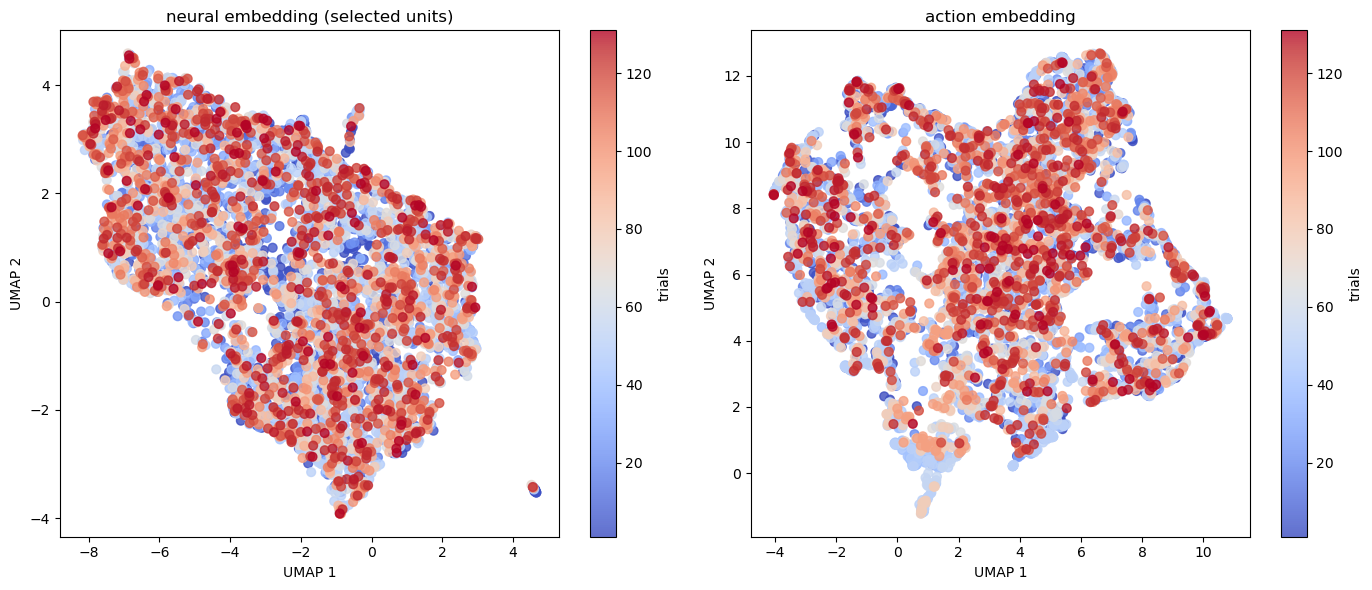

In [113]:
from umap import UMAP
import matplotlib.pyplot as plt

neural_selected = neural_df_correct[selected_units].fillna(0)

# fit UMAP on the selected neural activity
reducer = UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.1)
neural_embedding = reducer.fit_transform(neural_selected)

# also project action vectors into 2D for comparison
action_reducer = UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=0.1)
action_embedding = action_reducer.fit_transform(trial_df_correct.fillna(0))

# color by cue
# cues = beh[approach_mask].reset_index(drop=True)['cue'].reset_index(drop=True)
trials = beh[approach_mask].reset_index(drop=True)['trial_id'].reset_index(drop=True)
# track_zone_id = beh[approach_mask].reset_index(drop=True)['track_zone_int'].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, emb, title in zip(axes, 
                           [neural_embedding, action_embedding],
                           ['neural embedding (selected units)', 
                            'action embedding']):
    sc = ax.scatter(emb[:, 0], emb[:, 1], 
                    c=trials, cmap='coolwarm', 
                    alpha=0.8, s=40)
    plt.colorbar(sc, ax=ax, label='trials')
    ax.set_title(title)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

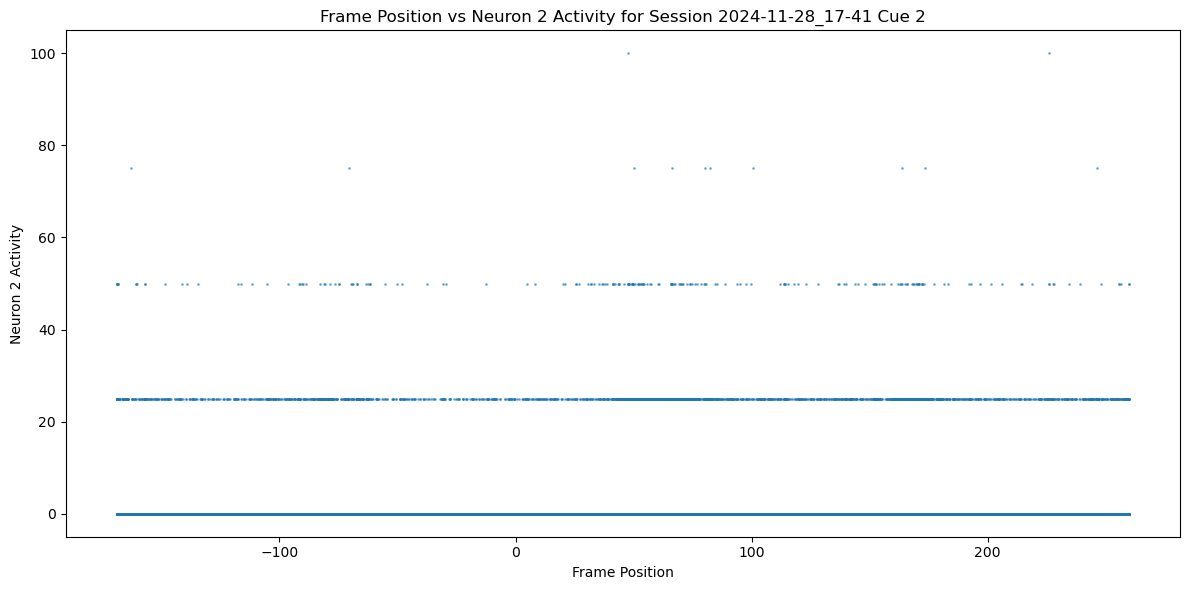

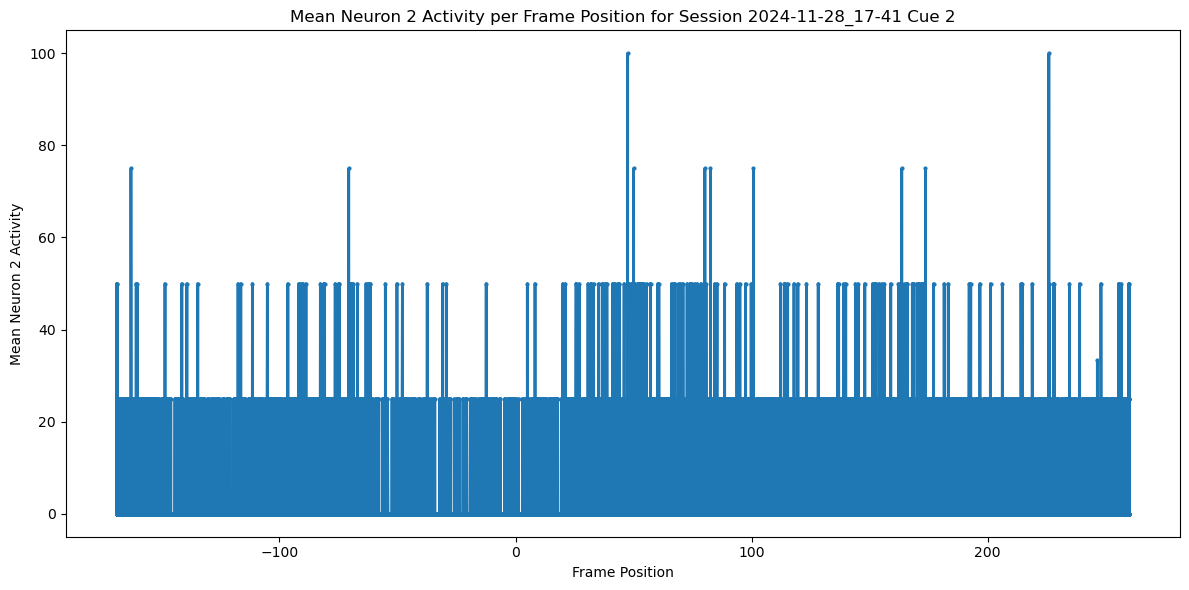

In [ ]:
import matplotlib.pyplot as plt

# Extract frame_position from behavior_glm_loaded
frame_position = last_only_2['frame_position'].values

# Extract neuron 2 from spikes_loaded
neuron_1 = fr_last_only_2.iloc[:, 1].values

# Create scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(frame_position, neuron_1, s=1, alpha=0.5)
plt.xlabel('Frame Position')
plt.ylabel('Neuron 2 Activity')
plt.title(f'Frame Position vs Neuron 2 Activity for Session 2024-11-28_17-41 Cue 2')
plt.tight_layout()
plt.show()

# Plot mean neuron activity per frame position
frame_position_unique = np.unique(frame_position)
mean_neuron_1_per_frame = []

for fp in frame_position_unique:
    mask = frame_position == fp
    mean_neuron_1_per_frame.append(neuron_1[mask].mean())

plt.figure(figsize=(12, 6))
plt.plot(frame_position_unique, mean_neuron_1_per_frame, linewidth=2, marker='o', markersize=2)
plt.xlabel('Frame Position')
plt.ylabel('Mean Neuron 2 Activity')
plt.title('Mean Neuron 2 Activity per Frame Position for Session 2024-11-28_17-41 Cue 2')
plt.tight_layout()
plt.show()

In [ ]:
# remove rows whose index tuple starts with 3

# behavior_glm_loaded = behavior_glm_loaded.astype(float)
# spikes_loaded = spikes_loaded.astype(float)

# full_data_behavior_mean = torch.from_numpy(behavior_glm_loaded.to_numpy()).mean(dim=0).to(torch.float32)
# full_data_behavior_std = torch.from_numpy(behavior_glm_loaded.to_numpy()).std(dim=0).to(torch.float32) + 1e-8

# full_data_spike_mean = torch.from_numpy(spikes_loaded.to_numpy()).mean(dim=0).to(torch.float32)
# full_data_spike_std = torch.from_numpy(spikes_loaded.to_numpy()).std(dim=0).to(torch.float32) + 1e-8

# behavior_glm_by_trial = {}
# spikes_loaded_by_trial = {}
# for i in unique_trials:
#     mask = behavior_glm_loaded.index.map(lambda t: t[0] == i)
#     if len(behavior_glm_loaded[mask]) == 0:
#         continue
#     behavior_glm_by_trial[i] = torch.from_numpy(behavior_glm_loaded[mask].to_numpy()).to(torch.float32)
#     spikes_loaded_by_trial[i] = (torch.from_numpy(spikes_loaded[mask].to_numpy()).to(torch.float32)).to(torch.float32)

# # Convert to z-scores
# for i in unique_trials:
#     behavior_glm_by_trial[i] = (behavior_glm_by_trial[i] - full_data_behavior_mean) / full_data_behavior_std
#     spikes_loaded_by_trial[i] = (spikes_loaded_by_trial[i] - full_data_spike_mean) / full_data_spike_std

In [ ]:
# remove rows whose index tuple starts with 3

behavior_glm_loaded = behavior_glm_loaded.astype(float)
spikes_loaded = spikes_loaded.astype(float)

full_data_behavior_mean = torch.from_numpy(behavior_glm_loaded.to_numpy()).mean(dim=0).to(torch.float32)
full_data_behavior_std = torch.from_numpy(behavior_glm_loaded.to_numpy()).std(dim=0).to(torch.float32) + 1e-8

full_data_spike_mean = torch.from_numpy(spikes_loaded.to_numpy()).mean(dim=0).to(torch.float32)
full_data_spike_std = torch.from_numpy(spikes_loaded.to_numpy()).std(dim=0).to(torch.float32) + 1e-8

behavior_glm_by_trial = {}
spikes_loaded_by_trial = {}
for i in unique_trials:
    mask = behavior_glm_loaded.index.map(lambda t: t[0] == i)
    if len(behavior_glm_loaded[mask]) == 0:
        continue
    behavior_glm_by_trial[i] = torch.from_numpy(behavior_glm_loaded[mask].to_numpy()).to(torch.float32)
    spikes_loaded_by_trial[i] = (torch.from_numpy(spikes_loaded[mask].to_numpy()).to(torch.float32)).to(torch.float32)

# Convert to z-scores
for i in unique_trials:
    behavior_glm_by_trial[i] = (behavior_glm_by_trial[i] - full_data_behavior_mean) / full_data_behavior_std
    spikes_loaded_by_trial[i] = (spikes_loaded_by_trial[i] - full_data_spike_mean) / full_data_spike_std

In [ ]:
behavior_glm_loaded.shape

(203821, 26)

In [ ]:
behavior_glm_by_trial.keys()

dict_keys(['2024-11-14_16-40', '2024-11-21_17-22', '2024-11-26_16-39', '2024-11-20_17-46', '2024-11-15_15-48', '2024-11-25_16-25', '2024-11-28_17-41'])

In [ ]:
(torch.from_numpy(spikes_loaded["Unit0002"].unique()) - full_data_spike_mean[1]) / full_data_spike_std[1]

tensor([-0.3428,  2.3950,  5.1327,  7.8705, 10.6082, 13.3460, 16.0837],
       dtype=torch.float64)

In [ ]:
unique_set = set()
for i in range(1, 78):
    curr = spikes_loaded[f"Unit00{i:02d}"].unique()
    for elem in curr:
        unique_set.add(elem)

print(unique_set)

{np.float64(0.0), np.float64(400.0), np.float64(275.0), np.float64(150.0), np.float64(25.0), np.float64(425.0), np.float64(300.0), np.float64(175.0), np.float64(50.0), np.float64(450.0), np.float64(325.0), np.float64(200.0), np.float64(75.0), np.float64(350.0), np.float64(225.0), np.float64(100.0), np.float64(375.0), np.float64(250.0), np.float64(125.0)}


In [ ]:
from tqdm import tqdm
accuracy = []
false_positive_rate = []
false_negative_rate = []
mse_loss = []
for held_out_trial in behavior_glm_by_trial.keys():
    print(f"Held-out trial: {held_out_trial}")
    train_trials = [x for x in behavior_glm_by_trial.keys() if x != held_out_trial]  # Exclude the held-out trial

    epochs = 1000
    model = MLP(input_size=26, hidden_size=64, num_hidden_layers=2, output_size=1).cuda()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=100, factor=0.5)


    train_losses = []
    for epoch in tqdm(range(epochs), desc="Training"):
        curr_train_losses = []
        
        model.train()
        optimizer.zero_grad()
        for session_id in train_trials:
            inputs = behavior_glm_by_trial[session_id]
            labels = spikes_loaded_by_trial[session_id]
            inputs = inputs.cuda()  # Ensure inputs are float tensors
            labels = labels.cuda()[:, 1:2]  # Ensure labels are float tensors
            # print(labels)
            # import ipdb; ipdb.set_trace()

            hidden, outputs = model(inputs)
            loss = torch.nn.functional.mse_loss(outputs, labels)
            loss.backward()
            optimizer.step()
            
            curr_train_losses.append(loss.item())
            del inputs, labels, hidden, outputs, loss  # Free up memory
            optimizer.zero_grad()  # Clear gradients for the next iteration
            torch.cuda.empty_cache()  # Clear GPU cache to free up memory
        curr_mean_loss = np.mean(curr_train_losses)
        scheduler.step(curr_mean_loss)
        train_losses.append(curr_mean_loss)
    
    print(f"Train Loss at last epoch: {curr_mean_loss}")

    # per_index_accuracy = {i: [] for i in range(77)}
    # per_index_false_positive_rate = {i: [] for i in range(77)}
    # per_index_false_negative_rate = {i: [] for i in range(77)}
    with torch.no_grad():
        inputs = behavior_glm_by_trial[held_out_trial]
        labels = spikes_loaded_by_trial[held_out_trial]
        inputs = inputs.cuda()  # Ensure inputs are float tensors
        labels = labels.cuda()  # Ensure labels are float tensors

        hidden, outputs = model(inputs)
        predicted = (outputs).float()  # Binarize predictions
        mse_loss.append(torch.nn.functional.mse_loss(outputs, labels[:, 1:2]).item())
        print(f"MSE Loss for trial {held_out_trial}: {mse_loss[-1]}")
        # correct = (predicted == labels).float().sum()
        # total = labels.numel()
        # acc = correct / total

        # accuracy.append(acc.item())

        # Compute false positive and false negative rates
        # false_pos = ((predicted == 1) & (labels == 0)).float().sum()
        # false_neg = ((predicted == 0) & (labels == 1)).float().sum()
        # fp_rate = false_pos / (false_pos + (labels == 0).float().sum())
        # fn_rate = false_neg / (false_neg + (labels == 1).float().sum())
        # false_positive_rate.append(fp_rate.item())
        # false_negative_rate.append(fn_rate.item())

        # print(f"Accuracy for held-out trial {held_out_trial}: {acc.item():.4f}")
        # print(f"False Positive Rate for held-out trial {held_out_trial}: {fp_rate.item():.4f}")
        # print(f"False Negative Rate for held-out trial {held_out_trial}: {fn_rate.item():.4f}")

        # Compute per-index accuracy
        # for i in range(1, 2):
        #     idx_correct = ((predicted == labels[:, i])).float().sum()
        #     idx_total = len(labels[:, i])
        #     false_pos = ((predicted == 1) & (labels[:, i] == 0)).float().sum()
        #     false_neg = ((predicted == 0) & (labels[:, i] == 1)).float().sum()
        #     if idx_total > 0:
        #         per_index_accuracy[i].append((idx_correct / idx_total).item())
        #         per_index_false_positive_rate[i].append((false_pos / (false_pos + (labels[:, i] == 0).float().sum())).item())
        #         per_index_false_negative_rate[i].append((false_neg / (false_neg + (labels[:, i] == 1).float().sum())).item())

# print(f"Average Accuracy: {np.mean(accuracy):.4f}")
# print(f"Average False Positive Rate: {np.mean(false_positive_rate):.4f}")
# print(f"Average False Negative Rate: {np.mean(false_negative_rate):.4f}")

# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 6))
# # plot per-index accuracy as a color coded table
# plt.subplot(1, 2, 1)
# plt.bar(per_index_accuracy.keys(), [np.mean(per_index_accuracy[i]) for i in per_index_accuracy.keys()])
# plt.xlabel("Neuron Index")
# plt.ylabel("Average Accuracy")
# plt.title("Per-Neuron Accuracy")
# plt.show()

# plt.figure(figsize=(12, 6))
# # plot per-index false positive rate as a color coded table
# plt.subplot(1, 2, 1)
# plt.bar(per_index_false_positive_rate.keys(), [np.mean(per_index_false_positive_rate[i])
#             for i in per_index_false_positive_rate.keys()])
# plt.xlabel("Neuron Index")
# plt.ylabel("Average False Positive Rate")
# plt.title("Per-Neuron False Positive Rate")
# plt.show()

# plt.figure(figsize=(12, 6))
# # plot per-index false negative rate as a color coded table
# plt.subplot(1, 2, 1)
# plt.bar(per_index_false_negative_rate.keys(), [np.mean(per_index_false_negative_rate[i])
#             for i in per_index_false_negative_rate.keys()])
# plt.xlabel("Neuron Index")
# plt.ylabel("Average False Negative Rate")
# plt.title("Per-Neuron False Negative Rate")
# plt.show()

print(f"Average MSE Loss: {np.mean(mse_loss):.4f}")

Held-out trial: 2024-11-20_17-46


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Training: 100%|██████████| 1000/1000 [00:41<00:00, 23.95it/s]


Train Loss at last epoch: 0.7354859138528506
MSE Loss for trial 2024-11-20_17-46: 2.117454767227173
Held-out trial: 2024-11-15_15-48


Training: 100%|██████████| 1000/1000 [00:35<00:00, 28.52it/s]


...

Train Loss at last epoch: 1.02009051044782
MSE Loss for trial 2024-11-14_16-40: 0.1778832972049713
Held-out trial: 2024-11-25_16-25


Training: 100%|██████████| 1000/1000 [00:36<00:00, 27.42it/s]


Train Loss at last epoch: 0.8662361154953638
MSE Loss for trial 2024-11-25_16-25: 1.7794101238250732
Held-out trial: 2024-11-21_17-22


Training: 100%|██████████| 1000/1000 [00:33<00:00, 29.47it/s]

Train Loss at last epoch: 0.8472304940223694
MSE Loss for trial 2024-11-21_17-22: 1.8419055938720703
Average MSE Loss: 1.2906


In [62]:
behavior_glm_by_trial.keys()

dict_keys(['2024-11-14_16-40', '2024-11-21_17-22', '2024-11-26_16-39', '2024-11-20_17-46', '2024-11-15_15-48', '2024-11-25_16-25', '2024-11-28_17-41'])

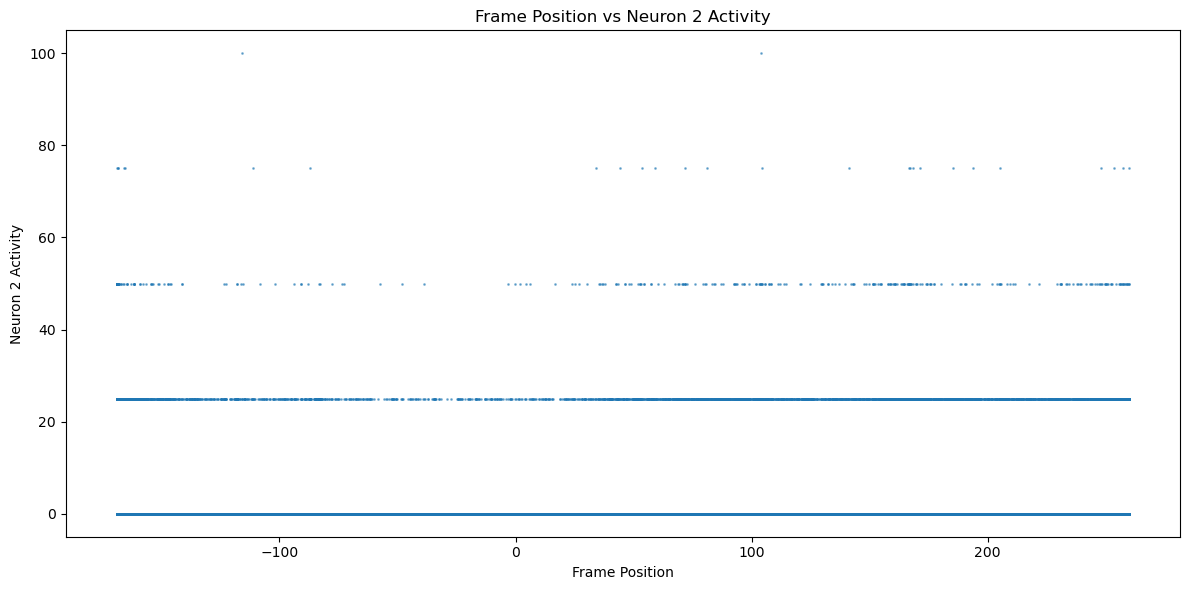

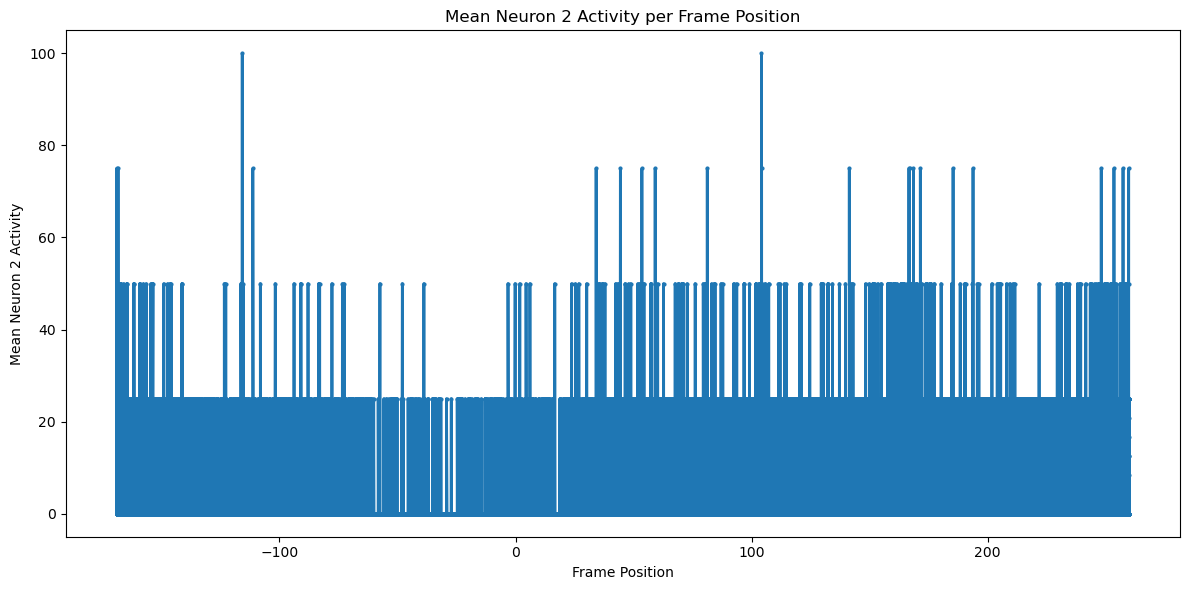

In [64]:
import matplotlib.pyplot as plt

# Extract frame_position from behavior_glm_loaded
mask = behavior_glm_loaded.index.map(lambda t: t[0] == "2024-11-26_16-39")
frame_position = behavior_glm_loaded[mask]['frame_position'].values

# Extract neuron 2 from spikes_loaded
neuron_1 = spikes_loaded[mask].iloc[:, 1].values

# Create scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(frame_position, neuron_1, s=1, alpha=0.5)
plt.xlabel('Frame Position')
plt.ylabel('Neuron 2 Activity')
plt.title('Frame Position vs Neuron 2 Activity')
plt.tight_layout()
plt.show()

# Plot mean neuron activity per frame position
frame_position_unique = np.unique(frame_position)
mean_neuron_1_per_frame = []

for fp in frame_position_unique:
    mask = frame_position == fp
    mean_neuron_1_per_frame.append(neuron_1[mask].mean())

plt.figure(figsize=(12, 6))
plt.plot(frame_position_unique, mean_neuron_1_per_frame, linewidth=2, marker='o', markersize=2)
plt.xlabel('Frame Position')
plt.ylabel('Mean Neuron 2 Activity')
plt.title('Mean Neuron 2 Activity per Frame Position')
plt.tight_layout()
plt.show()

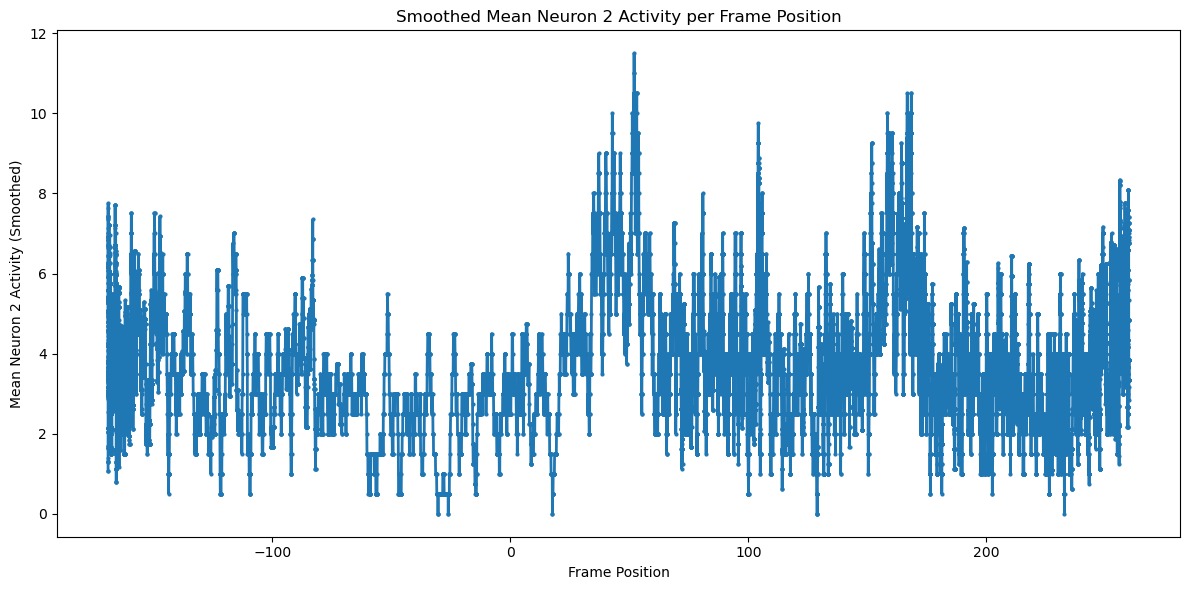

In [67]:
from scipy.ndimage import uniform_filter1d

# Apply box filter (uniform filter) to smooth both arrays
window_size = 50  # Adjust this for desired smoothing strength

frame_position_unique_smooth = uniform_filter1d(frame_position_unique, size=window_size, mode='mirror')
mean_neuron_1_per_frame_smooth = uniform_filter1d(mean_neuron_1_per_frame, size=window_size, mode='mirror')

# Plot smoothed data
plt.figure(figsize=(12, 6))
plt.plot(frame_position_unique_smooth, mean_neuron_1_per_frame_smooth, linewidth=2, marker='o', markersize=2)
plt.xlabel('Frame Position')
plt.ylabel('Mean Neuron 2 Activity (Smoothed)')
plt.title('Smoothed Mean Neuron 2 Activity per Frame Position')
plt.tight_layout()



plt.show()

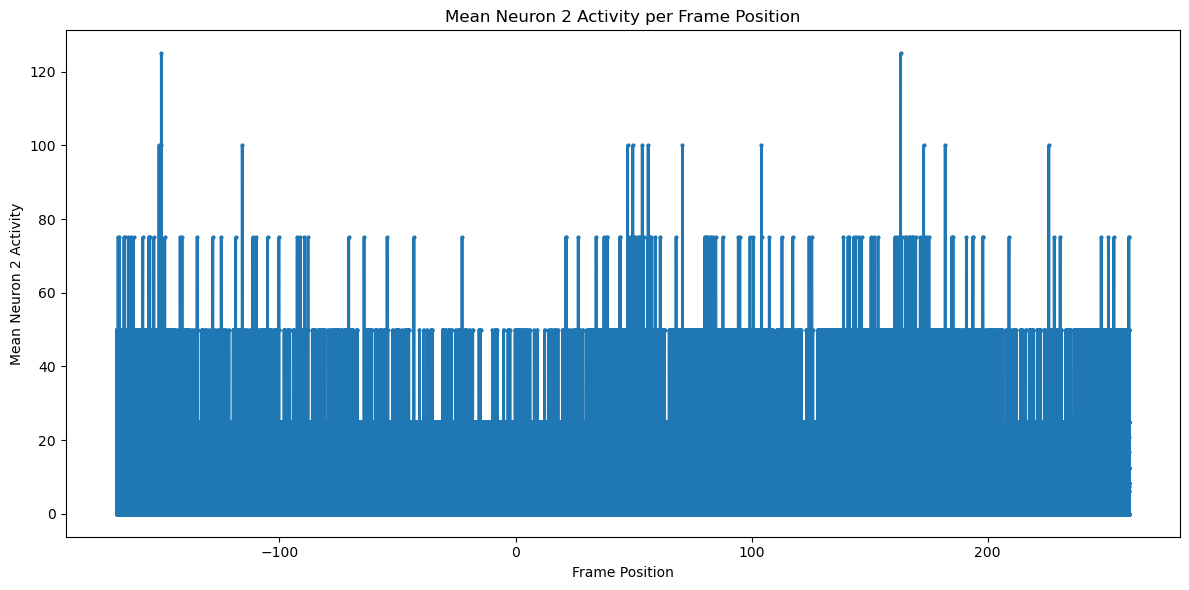

In [61]:
plt.figure(figsize=(12, 6))
plt.plot(frame_position_unique, mean_neuron_1_per_frame, linewidth=2, marker='o', markersize=2)
plt.xlabel('Frame Position')
plt.ylabel('Mean Neuron 2 Activity')
plt.title('Mean Neuron 2 Activity per Frame Position')
plt.tight_layout()
plt.show()

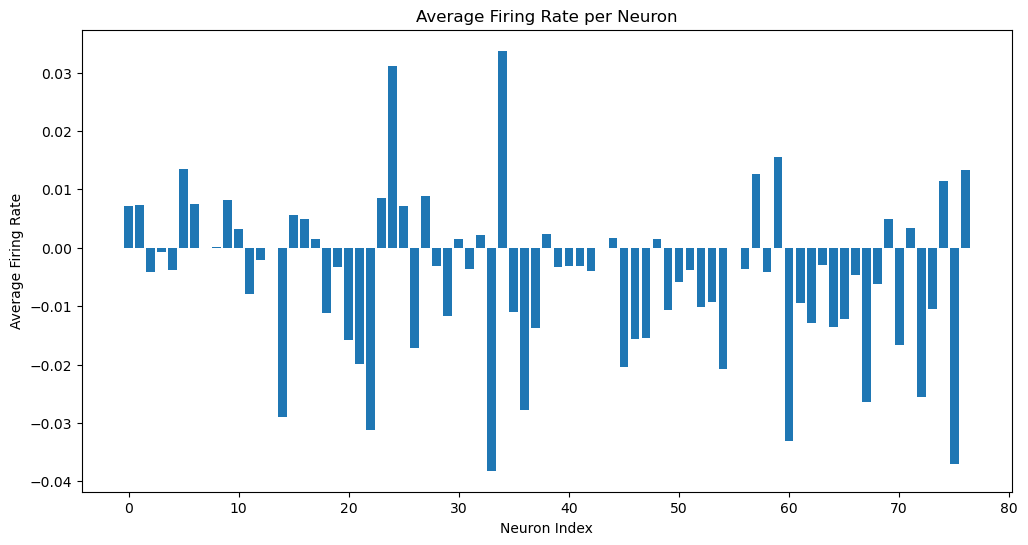

In [20]:
label_distributions = {i: [] for i in range(77)}
for trial in spikes_loaded_by_trial.keys():
    labels = spikes_loaded_by_trial[trial]
    for i in range(77):
        label_distributions[i].append(labels[:, i].float().mean().item())

plt.figure(figsize=(12, 6))
plt.bar(label_distributions.keys(), [np.mean(label_distributions[i]) for i in label_distributions.keys()])
plt.xlabel("Neuron Index")
plt.ylabel("Average Firing Rate")
plt.title("Average Firing Rate per Neuron")
plt.show()

Neurons with intermediate firing rates: []


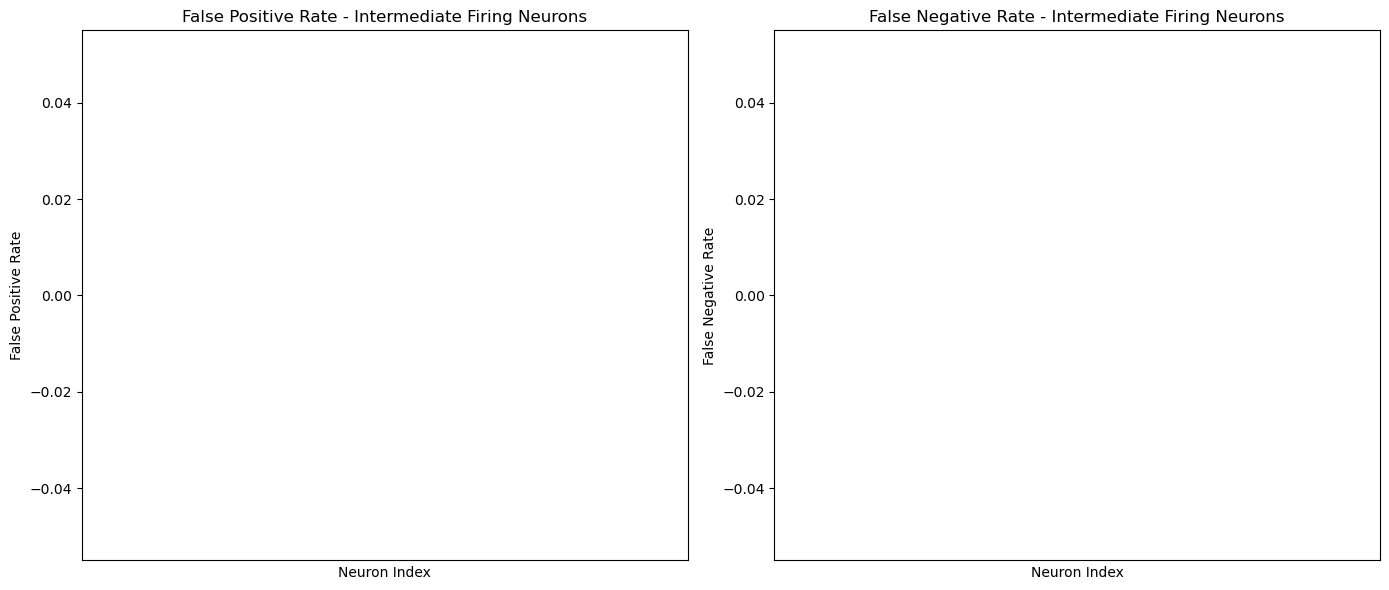


Firing rates for intermediate neurons:


In [21]:
# Filter neurons with intermediate firing rates (not mostly zero or one)
intermediate_neurons = []
for i in range(77):
    mean_firing = np.mean(label_distributions[i])
    if 0.1 < mean_firing < 0.9:  # neurons firing 10-90% of the time
        intermediate_neurons.append(i)

print(f"Neurons with intermediate firing rates: {intermediate_neurons}")

# Plot FP and FN rates for intermediate neurons
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# plt.bar(intermediate_neurons, [np.mean([per_index_false_positive_rate[i][0] if not np.isnan(per_index_false_positive_rate[i][0]) else 0 for i in intermediate_neurons])]*len(intermediate_neurons) 
#         if intermediate_neurons else [])
plt.bar(intermediate_neurons, [np.mean(per_index_false_positive_rate[i]) if per_index_false_positive_rate[i] else 0 for i in intermediate_neurons])
plt.xlabel("Neuron Index")
plt.ylabel("False Positive Rate")
plt.title("False Positive Rate - Intermediate Firing Neurons")
plt.xticks(intermediate_neurons, rotation=45)

plt.subplot(1, 2, 2)
# plt.bar(intermediate_neurons, [np.mean([per_index_false_negative_rate[i][0] if not np.isnan(per_index_false_negative_rate[i][0]) else 0 for i in intermediate_neurons])]*len(intermediate_neurons)
#         if intermediate_neurons else [])
plt.bar(intermediate_neurons, [np.nanmean(per_index_false_negative_rate[i]) if per_index_false_negative_rate[i] else 0 for i in intermediate_neurons])
plt.xlabel("Neuron Index")
plt.ylabel("False Negative Rate")
plt.title("False Negative Rate - Intermediate Firing Neurons")
plt.xticks(intermediate_neurons, rotation=45)

plt.tight_layout()
plt.show()

# Show the firing rates for these neurons
print("\nFiring rates for intermediate neurons:")
for i in intermediate_neurons:
    print(f"Neuron {i}: {np.mean(label_distributions[i]):.4f}")

In [22]:
for model in [LSTM(input_size=12, hidden_size=32, output_size=77).cuda(), RNN(input_size=12, hidden_size=32, output_size=77).cuda()]:
    print(f"Model: {model.__class__.__name__}")
    total_params = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total_params += num_params
            print(f"{name}: {num_params} parameters")

    print(f"Total parameters: {total_params}")

Model: LSTM
lstm.weight_ih_l0: 1536 parameters
lstm.weight_hh_l0: 4096 parameters
lstm.bias_ih_l0: 128 parameters
lstm.bias_hh_l0: 128 parameters
fc.0.weight: 2048 parameters
fc.0.bias: 64 parameters
fc.2.weight: 4928 parameters
fc.2.bias: 77 parameters
Total parameters: 13005
Model: RNN
rnn.weight_ih_l0: 384 parameters
rnn.weight_hh_l0: 1024 parameters
rnn.bias_ih_l0: 32 parameters
rnn.bias_hh_l0: 32 parameters
fc.0.weight: 2048 parameters
fc.0.bias: 64 parameters
fc.2.weight: 4928 parameters
fc.2.bias: 77 parameters
Total parameters: 8589


In [23]:

model = cebra.models.init('offset10-model', num_neurons=77, num_units=12, num_output=32)

total_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        num_params = param.numel()
        total_params += num_params
        print(f"{name}: {num_params} parameters")
total_params

net.0.weight: 1848 parameters
net.0.bias: 12 parameters
net.2.module.0.weight: 432 parameters
net.2.module.0.bias: 12 parameters
net.3.module.0.weight: 432 parameters
net.3.module.0.bias: 12 parameters
net.4.module.0.weight: 432 parameters
net.4.module.0.bias: 12 parameters
net.5.weight: 1152 parameters
net.5.bias: 32 parameters


4376

In [24]:

# 1. Define a CEBRA model
cebra_model = CEBRA(
    model_architecture="offset10-model", #consider: "offset10-model-mse" if Euclidean
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.12,
    max_iterations=5000, #we will sweep later; start with default
    conditional='time', #for supervised, put 'time_delta', or 'delta'
    output_dimension=3,
    distance='cosine', #consider 'euclidean'; if you set this, output_dimension min=2
    device="cuda_if_available",
    verbose=True,
    time_offsets=10
)

In [25]:
exclude_trials = []
train_trials = [x for x in behavior_glm_by_trial.keys() if x not in exclude_trials]
train_data = torch.cat([behavior_glm_by_trial[trial] for trial in train_trials], dim=0).numpy()
train_labels = torch.cat([spikes_loaded_by_trial[trial] for trial in train_trials], dim=0).numpy()

In [26]:


# fit
cebra_time_full_model = cebra_model.fit(train_data)
# transform
cebra_time_full = cebra_model.transform(train_data)
# GoF
gof_full = cebra.sklearn.metrics.goodness_of_fit_score(cebra_time_full_model, train_data)
print(" GoF in bits - full:", gof_full)


pos: -0.8926 neg:  6.3676 total:  5.4750 temperature:  1.1200: 100%|██████████| 5000/5000 [01:58<00:00, 42.09it/s] 
100%|██████████| 500/500 [00:04<00:00, 113.37it/s]

 GoF in bits - full: 1.0996648749124085


<Figure size 500x500 with 0 Axes>

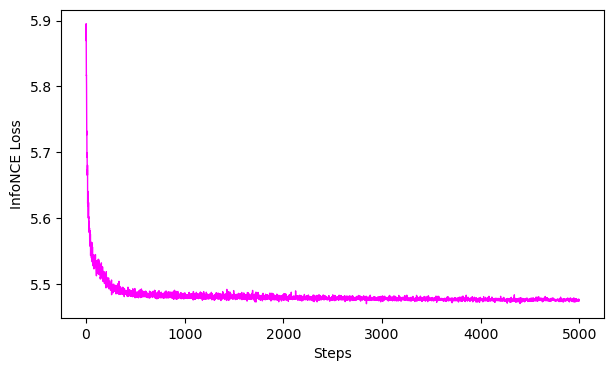

In [27]:
# plot embedding
fig = cebra.integrations.plotly.plot_embedding_interactive(cebra_time_full, embedding_labels=train_labels[:,2], title = "CEBRA-Time (full)", markersize=3, cmap = "rainbow")
fig.show()
# plot the loss curve
ax = cebra.plot_loss(cebra_time_full_model)

In [28]:
behavior_glm_by_trial.keys()

dict_keys(['2024-11-20_17-46', '2024-11-15_15-48', '2024-11-26_16-39', '2024-11-28_17-41', '2024-11-14_16-40', '2024-11-25_16-25', '2024-11-21_17-22'])

In [29]:
val_trials = [x for x in behavior_glm_by_trial.keys() if x != '2024-11-21_17-22']  # Exclude trial 3
train_trials = [x for x in behavior_glm_by_trial.keys() if x not in val_trials]
train_data = torch.cat([behavior_glm_by_trial[trial] for trial in train_trials], dim=0).numpy()
train_labels = torch.cat([spikes_loaded_by_trial[trial] for trial in train_trials], dim=0).numpy()
validation_data = torch.cat([behavior_glm_by_trial[trial] for trial in val_trials], dim=0).numpy()
validation_labels = torch.cat([spikes_loaded_by_trial[trial] for trial in val_trials], dim=0).numpy()

In [30]:

for neuron_idx in range(train_labels.shape[1]):

    cebra_behavior_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=3,
                        max_iterations=5000,
                        distance='cosine',
                        conditional='time_delta', #using labels
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)
    

    # fit
    cebra_time_full_model = cebra_behavior_model.fit(train_data, train_labels[:, neuron_idx])
    # transform
    # cebra_time_full = cebra_behavior_model.transform(train_data)
    # GoF
    gof_full = cebra.sklearn.metrics.goodness_of_fit_score(cebra_time_full_model, train_data, train_labels[:, neuron_idx])
    print(f"Neuron {neuron_idx}: GoF in bits - full: {gof_full}")

pos: -0.6384 neg:  6.7230 total:  6.0846 temperature:  1.0000: 100%|██████████| 5000/5000 [01:57<00:00, 42.47it/s] 
100%|██████████| 500/500 [00:05<00:00, 94.10it/s] 


Neuron 0: GoF in bits - full: 0.22086674229299175


pos: -0.6446 neg:  6.7195 total:  6.0749 temperature:  1.0000: 100%|██████████| 5000/5000 [01:57<00:00, 42.60it/s] 
100%|██████████| 500/500 [00:05<00:00, 93.11it/s] 


Neuron 1: GoF in bits - full: 0.22088757558338667


pos: -0.6559 neg:  6.7274 total:  6.0715 temperature:  1.0000: 100%|██████████| 5000/5000 [01:57<00:00, 42.38it/s] 
100%|██████████| 500/500 [00:05<00:00, 92.52it/s] 


...

Neuron 53: GoF in bits - full: 0.22397658899620282


pos: -0.6526 neg:  6.7315 total:  6.0789 temperature:  1.0000: 100%|██████████| 5000/5000 [01:58<00:00, 42.11it/s] 
100%|██████████| 500/500 [00:05<00:00, 87.88it/s]


Neuron 54: GoF in bits - full: 0.22411786517664875


pos: -0.6176 neg:  6.7070 total:  6.0894 temperature:  1.0000:  90%|█████████ | 4506/5000 [01:49<00:12, 41.01it/s] 


KeyboardInterrupt: 

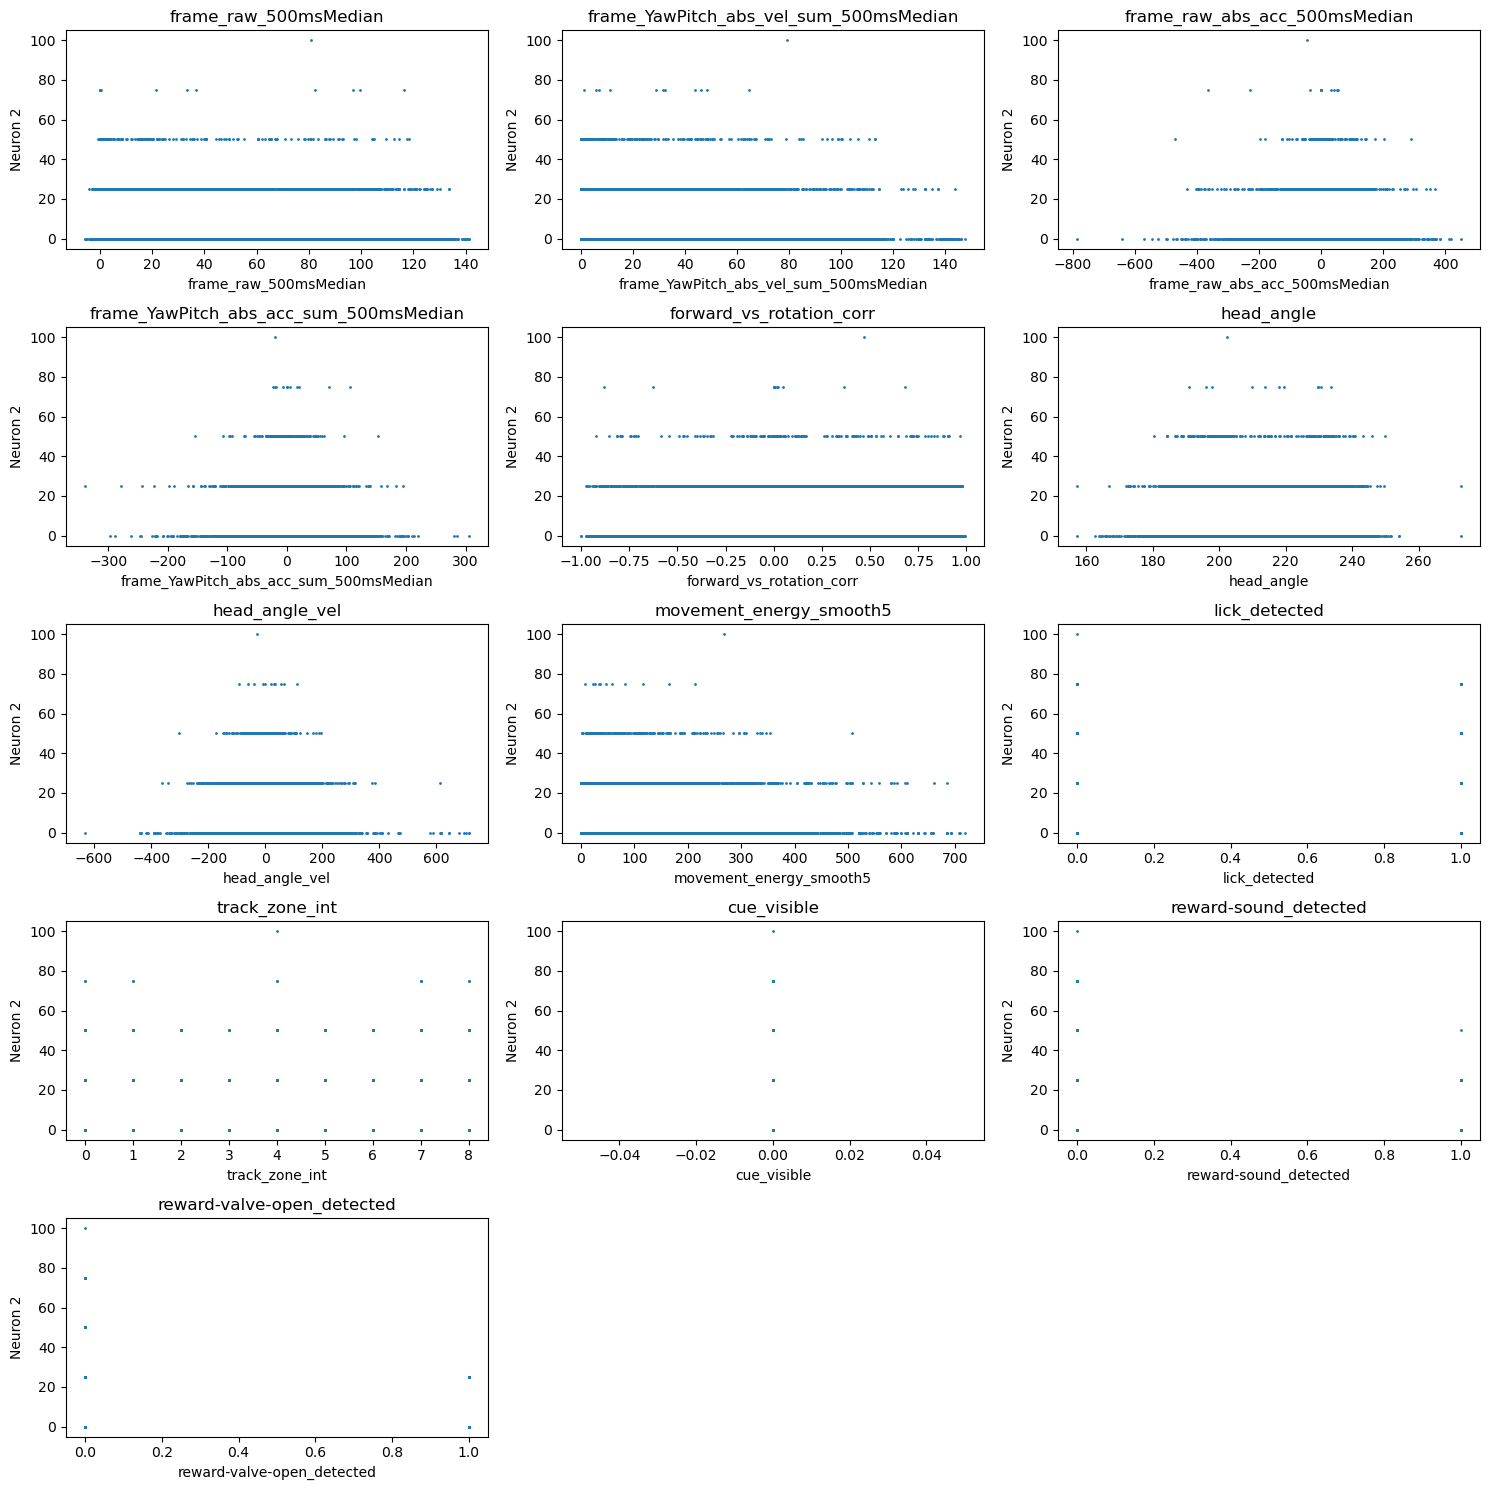

In [ ]:
neuron_idx = 1

import matplotlib.pyplot as plt

# pick a trial (any one)
trial = list(behavior_glm_by_trial.keys())[-1]

beh = behavior_glm_by_trial[trial].cpu().numpy()
spikes = spikes_loaded_by_trial[trial].cpu().numpy()
neuron = spikes[:, neuron_idx]

cols = list(behavior_glm_loaded.columns)
ncols = len(cols)
nrows = (ncols + 2) // 3

fig, axes = plt.subplots(nrows, 3, figsize=(15, nrows * 3), squeeze=False)
for i, col in enumerate(cols):
    r = i // 3
    c = i % 3
    ax = axes[r][c]
    ax.scatter(beh[:, i], neuron, s=1)
    ax.set_xlabel(col)
    ax.set_ylabel(f"Neuron {neuron_idx + 1}")
    ax.set_title(col)

# hide any unused subplots
for j in range(ncols, nrows * 3):
    fig.delaxes(axes[j // 3][j % 3])

plt.tight_layout()
plt.show()

In [ ]:
best_neuron = 1

shuffled_pos = np.random.permutation(train_labels[:,best_neuron])

cebra_shuffled_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=3,
                        max_iterations=5000,
                        distance='cosine',
                        conditional='time_delta',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)

cebra_shuffled_model.fit(train_data, shuffled_pos)

gof_full = cebra.sklearn.metrics.goodness_of_fit_score(cebra_shuffled_model, validation_data, validation_labels[:, best_neuron])
gof_full

pos: -0.6165 neg:  6.7166 total:  6.1001 temperature:  1.0000: 100%|██████████| 5000/5000 [01:54<00:00, 43.50it/s] 
100%|██████████| 500/500 [00:04<00:00, 106.17it/s]


np.float64(-0.09172869964987289)

In [ ]:
iterations = 3

for _ in range(iterations):
    cebra_shuffled_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4,
                        temperature=1,
                        output_dimension=3,
                        max_iterations=5000,
                        distance='cosine',
                        conditional='time_delta',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)
    shuffled_pos = np.random.permutation(train_labels[:,best_neuron])
    cebra_shuffled_model.fit(train_data, shuffled_pos)
    gof_full = cebra.sklearn.metrics.goodness_of_fit_score(cebra_shuffled_model, validation_data, validation_labels[:, best_neuron])
    print(f"Shuffled GoF in bits: {gof_full}")

for _ in range(iterations):
    cebra_behavior_model = CEBRA(model_architecture='offset10-model',
                        batch_size=512,
                        learning_rate=3e-4, temperature=1,
                        output_dimension=3,
                        max_iterations=5000,
                        distance='cosine',
                        conditional='time_delta',
                        device='cuda_if_available',
                        verbose=True,
                        time_offsets=10)
    cebra_behavior_full_model = cebra_behavior_model.fit(train_data, train_labels[:, best_neuron])
    gof_full = cebra.sklearn.metrics.goodness_of_fit_score(cebra_behavior_full_model, validation_data, validation_labels[:, best_neuron])
    print(f"Full GoF in bits: {gof_full}")

pos: -0.8367 neg:  7.0804 total:  6.2437 temperature:  1.0000:   0%|          | 0/5000 [00:00<?, ?it/s]

pos: -0.6236 neg:  6.7035 total:  6.0798 temperature:  1.0000: 100%|██████████| 5000/5000 [01:54<00:00, 43.64it/s] 
100%|██████████| 500/500 [00:05<00:00, 99.60it/s] 


Shuffled GoF in bits: -0.03952810307060265


pos: -0.6367 neg:  6.7134 total:  6.0766 temperature:  1.0000: 100%|██████████| 5000/5000 [01:53<00:00, 44.23it/s] 
100%|██████████| 500/500 [00:05<00:00, 93.46it/s] 


Shuffled GoF in bits: 0.09031651990465865


...

Full GoF in bits: -0.41272540603226815


pos: -0.6614 neg:  6.7191 total:  6.0576 temperature:  1.0000: 100%|██████████| 5000/5000 [02:00<00:00, 41.64it/s] 
100%|██████████| 500/500 [00:05<00:00, 94.72it/s] 


Full GoF in bits: 0.09356888519098666


pos: -0.6257 neg:  6.7222 total:  6.0965 temperature:  1.0000: 100%|██████████| 5000/5000 [02:02<00:00, 40.79it/s] 
100%|██████████| 500/500 [00:05<00:00, 90.97it/s] 


Full GoF in bits: 0.07939081293995331


In [ ]:

# --- Register the custom 2-layer MLP ---
@cebra.models.register("mlp2-model")
class MLP2Layer(cebra.models.model.Model):
    """
    2-layer MLP with no temporal receptive field (offset=0).
    Input: (batch, num_input) — single timestep
    Output: (batch, num_output) — embedding
    """
    def __init__(self, num_input, num_output, hidden_size=128):
        super().__init__(num_input=num_input, num_output=num_output)
        self.net = nn.Sequential(
            nn.Linear(num_input, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_output),
        )
        # L2 normalize output to hypersphere (matches cosine distance)
        self.norm = nn.functional.normalize

    def get_offset(self):
        return Offset(0, 0)

    def forward(self, x):
        # x shape from CEBRA: (batch, num_input, time)
        # squeeze time dim since offset=0 means time=1
        x = x.squeeze(-1)           # → (batch, num_input)
        out = self.net(x)            # → (batch, num_output)
        out = self.norm(out, dim=-1) # normalize to hypersphere
        return out.unsqueeze(-1)     # → (batch, num_output, 1)


In [ ]:



# --- Updated training loop ---
for neuron_idx in range(train_labels.shape[1]):
    cebra_behavior_model = CEBRA(
        model_architecture='mlp2-model',  # use our registered model
        batch_size=512,
        learning_rate=3e-4,
        temperature=1,
        output_dimension=3,
        max_iterations=5000,
        distance='cosine',
        conditional='time_delta',
        device='cuda_if_available',
        verbose=True,
        time_offsets=1,  # set to 1 since MLP has no receptive field
    )

    cebra_time_full_model = cebra_behavior_model.fit(
        train_data, train_labels[:, neuron_idx]
    )

    gof_full = cebra.sklearn.metrics.goodness_of_fit_score(
        cebra_time_full_model,
        validation_data,
        validation_labels[:, neuron_idx]
    )
    print(f"Neuron {neuron_idx}: GoF in bits - MLP2: {gof_full}")

TypeError: MLP2Layer.__init__() got an unexpected keyword argument 'num_neurons'